In [91]:
# IMPORTS
import torch
import torch.nn as nn
from binn import BINN
import data_handling as dh
import binn_training as bt
import custom_train_test_split as ctts
import scanpy as sc
import anndata as ad
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Supress warnings
#import warnings
#warnings.filterwarnings("ignore")

In [ ]:
# GLOBALS
ALL_CELLTYPES = [0,1,2,3,4,5,6,7,8]
TRAIN_SIZE = 0.8
BATCH_SIZE = 32
EPOCHS = 400
MASK_PATHS = [f"/data/shared/alzgene26/PathwayData/MaskMatrixLayers/full_pipeline/mg_200_mc_200_mhvg1000/oligo_exc3_exc2_vasc_immune_astro_inhi_opcs_exc1_layer_{i}_mask.csv" 
              for i in range(5)]

# PARAMETERS
# OPTUNA: {'lr': 0.002204119007996014, 'weight_decay': 0.021469124496437196, 'dropout': 0.17634528194149005}
LR = 0.002204
WEIGHT_DECAY = 0.021469
DROPOUT = 0.176345
ACTIVATION_FN = nn.Tanh()

# OTHER
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# PATHS
base_path = "/data/shared/alzgene26/data"
data_path = base_path + "/processed_data/completed/full_pipeline/mg_200_mc_200_mhvg1000/"

In [93]:
print("Reading processed adata...")
datasets = ctts.read_files(to_include=ALL_CELLTYPES, filepath=data_path)

Reading processed adata...
Labels to include: ['astro', 'exc1', 'exc2', 'exc3', 'immune', 'inhi', 'oligo', 'opcs', 'vasc']
Reading astro
Reading exc1
Reading exc2
Reading exc3
Reading immune
Reading inhi
Reading oligo
Reading opcs
Reading vasc


In [94]:
datasets["astro"]

AnnData object with n_obs × n_vars = 1235 × 1000
    obs: 'subject', 'cell_type_high_resolution', 'n_obs_aggregated', 'AD_status'
    var: 'mean', 'std'
    uns: 'log1p'
    layers: 'mean', None

In [95]:
datasets["astro"].obs


,subject,cell_type_high_resolution,n_obs_aggregated,AD_status
ROSMAP-10132_Ast CHI3L1,ROSMAP-10132,Ast CHI3L1,14,1.0
ROSMAP-10132_Ast DPP10,ROSMAP-10132,Ast DPP10,138,1.0
ROSMAP-10132_Ast GRM3,ROSMAP-10132,Ast GRM3,508,1.0
ROSMAP-10643_Ast CHI3L1,ROSMAP-10643,Ast CHI3L1,29,2.0
ROSMAP-10643_Ast DPP10,ROSMAP-10643,Ast DPP10,57,2.0
...,...,...,...,...
ROSMAP-99585_Ast DPP10,ROSMAP-99585,Ast DPP10,99,1.0
ROSMAP-99585_Ast GRM3,ROSMAP-99585,Ast GRM3,12,1.0
ROSMAP-99981_Ast CHI3L1,ROSMAP-99981,Ast CHI3L1,8,2.0
ROSMAP-99981_Ast DPP10,ROSMAP-99981,Ast DPP10,31,2.0


In [96]:
# FROM GEMINI - Pseudobulk per patient only
patient_datasets = dh.rollup_to_patient_level(datasets)

Rolling up 'astro'...
Rolling up 'exc1'...
Rolling up 'exc2'...
Rolling up 'exc3'...
Rolling up 'immune'...
Rolling up 'inhi'...
Rolling up 'oligo'...
Rolling up 'opcs'...
Rolling up 'vasc'...


In [97]:
patient_datasets["astro"].obs

,subject,n_obs_mean,cell_type_high_resolution,AD_status
subject,,,,
ROSMAP-10132,ROSMAP-10132,220.000000,astro,1.0
ROSMAP-10643,ROSMAP-10643,165.000000,astro,2.0
ROSMAP-10859,ROSMAP-10859,101.000000,astro,1.0
ROSMAP-12078,ROSMAP-12078,74.333333,astro,1.0
ROSMAP-12256,ROSMAP-12256,139.666667,astro,2.0
...,...,...,...,...
ROSMAP-98582,ROSMAP-98582,133.000000,astro,2.0
ROSMAP-98683,ROSMAP-98683,64.000000,astro,2.0
ROSMAP-99419,ROSMAP-99419,310.666667,astro,2.0


In [98]:
print("Reading masks...")
masks = dh.read_masks(MASK_PATHS, print_shapes=True)

Reading masks...
Matrix 0 shape: (976, 764)
Matrix 1 shape: (764, 417)
Matrix 2 shape: (417, 163)
Matrix 3 shape: (163, 29)
Matrix 4 shape: (29, 1)


In [99]:
print("Aligning adatas to BINN...")
datasets_aligned = dh.subset_genes(patient_datasets, masks['df0'])

Aligning adatas to BINN...
Overlapping genes kept: 945 for astro
Overlapping genes kept: 945 for exc1
Overlapping genes kept: 945 for exc2
Overlapping genes kept: 945 for exc3
Overlapping genes kept: 945 for immune
Overlapping genes kept: 945 for inhi
Overlapping genes kept: 945 for oligo
Overlapping genes kept: 945 for opcs
Overlapping genes kept: 945 for vasc


In [100]:
datasets_aligned["astro"]

AnnData object with n_obs × n_vars = 427 × 945
    obs: 'subject', 'n_obs_mean', 'cell_type_high_resolution', 'AD_status'
    layers: None

In [101]:
print("Padding adatas to BINN-ready shape...")
datasets_padded = dh.pad_align_data(datasets_aligned, masks["df0"])
datasets_padded

Padding adatas to BINN-ready shape...


{'astro': AnnData object with n_obs × n_vars = 427 × 976
     obs: 'subject', 'n_obs_mean', 'cell_type_high_resolution', 'AD_status'
     layers: None,
 'exc1': AnnData object with n_obs × n_vars = 427 × 976
     obs: 'subject', 'n_obs_mean', 'cell_type_high_resolution', 'AD_status'
     layers: None,
 'exc2': AnnData object with n_obs × n_vars = 425 × 976
     obs: 'subject', 'n_obs_mean', 'cell_type_high_resolution', 'AD_status'
     layers: None,
 'exc3': AnnData object with n_obs × n_vars = 426 × 976
     obs: 'subject', 'n_obs_mean', 'cell_type_high_resolution', 'AD_status'
     layers: None,
 'immune': AnnData object with n_obs × n_vars = 426 × 976
     obs: 'subject', 'n_obs_mean', 'cell_type_high_resolution', 'AD_status'
     layers: None,
 'inhi': AnnData object with n_obs × n_vars = 423 × 976
     obs: 'subject', 'n_obs_mean', 'cell_type_high_resolution', 'AD_status'
     layers: None,
 'oligo': AnnData object with n_obs × n_vars = 427 × 976
     obs: 'subject', 'n_obs_mean',

In [102]:
# 
adata_global = dh.create_global_with_missing_patients(datasets_padded)

  Total unique subjects found: 427
  + Added astro (427 subjects)
  + Added exc1 (427 subjects)
  + Added exc2 (425 subjects)
  + Added exc3 (426 subjects)
  + Added immune (426 subjects)
  + Added inhi (423 subjects)
  + Added oligo (427 subjects)
  + Added opcs (427 subjects)
  + Added vasc (423 subjects)
Running Scanpy normalization...
Done! Final Global shape: (427, 976)


In [103]:
# Label sanity check 
adata_global.obs["AD_status"].value_counts()

AD_status
2.0    281
1.0     78
0.0     68
Name: count, dtype: int64

In [104]:
# Keep only rows where 'AD_status' is not equal to '2.0' (NOTE: string 2.0)
adata_global = adata_global[adata_global.obs["AD_status"] != '2.0'].copy()
adata_global.obs

,subject,AD_status,total_cells_all_types
ROSMAP-10132,ROSMAP-10132,1.0,3109.376667
ROSMAP-10859,ROSMAP-10859,1.0,2230.161111
ROSMAP-12078,ROSMAP-12078,1.0,3534.262222
ROSMAP-12832,ROSMAP-12832,1.0,2441.176667
ROSMAP-13327,ROSMAP-13327,0.0,3151.006667
...,...,...,...
ROSMAP-96967,ROSMAP-96967,0.0,2773.861111
ROSMAP-97067,ROSMAP-97067,1.0,1034.011905
ROSMAP-97816,ROSMAP-97816,0.0,891.555556
ROSMAP-97833,ROSMAP-97833,0.0,4037.553333


In [105]:
print("Creating global train/test split...")
train_adata_global, test_adata_global = ctts.custom_train_test_split(adata_global, train_size=TRAIN_SIZE)

Creating global train/test split...
Train Subjects: 116
Test Subjects: 30


In [106]:
print("Scaling genes to prevent leakage...")
train_adata_global, test_adata_global = dh.scaling_no_leakage(train_adata_global, test_adata_global)

Scaling genes to prevent leakage...


/data/users/thomath/kand/BINN/data_handling.py:359: ImplicitModificationWarning: Setting element `.X` of view, initializing view as actual.
  train_adata.X = scaler.fit_transform(train_X)
/data/users/thomath/kand/BINN/data_handling.py:360: ImplicitModificationWarning: Setting element `.X` of view, initializing view as actual.
  test_adata.X = scaler.transform(test_X)


In [107]:
print("Getting dataloaders...")
#train_loader, test_loader = dh.create_dataloaders(train_adata, test_adata)
train_loader_global, test_loader_global = dh.create_dataloaders(train_adata_global, test_adata_global, batch_size=BATCH_SIZE)

Getting dataloaders...


/data/users/thomath/kand/BINN/data_handling.py:100: FutureWarning: The function AnnLoader is deprecated and will be removed in the future. Use :class:`annbatch.Loader` instead of `AnnLoader`
  train_loader = AnnLoader(train_adata, batch_size=batch_size, shuffle=True)
/data/users/thomath/kand/BINN/data_handling.py:101: FutureWarning: The function AnnLoader is deprecated and will be removed in the future. Use :class:`annbatch.Loader` instead of `AnnLoader`
  test_loader = AnnLoader(test_adata, batch_size=batch_size, shuffle=False)


In [108]:
mask_matrix_list, in_features, layers_list, tensor_masks = dh.compute_features(masks, device)

input features: 976
layer list: [764, 417, 163, 29, 1]


In [109]:
# check for NaN-values etc.
dh.poison_scanner(train_loader_global, device)
dh.poison_scanner(test_loader_global, device)

No poison found!
No poison found!


In [110]:
# model is MLP with same layers as BINN 
binn, criterion, optimizer, scheduler = dh.create_model(in_features, layers_list, tensor_masks, device, 
                                                        lr=LR, weight_decay=WEIGHT_DECAY, dropout=DROPOUT, activation_fn=ACTIVATION_FN)
# Best hyperparams from Optuna {'lr': 0.009763668935486306, 'weight_decay': 0.09966656513852097, 'dropout': 0.16985580651321033}
binn

BINN(
  (activation_fn): Tanh()
  (dropout): Dropout(p=0.176345, inplace=False)
  (model_layers): ModuleList(
    (0): Linear(in_features=976, out_features=764, bias=True)
    (1): Linear(in_features=764, out_features=417, bias=True)
    (2): Linear(in_features=417, out_features=163, bias=True)
    (3): Linear(in_features=163, out_features=29, bias=True)
    (4): Linear(in_features=29, out_features=1, bias=True)
  )
  (layer_norms): ModuleList(
    (0): LayerNorm((764,), eps=1e-05, elementwise_affine=True, bias=True)
    (1): LayerNorm((417,), eps=1e-05, elementwise_affine=True, bias=True)
    (2): LayerNorm((163,), eps=1e-05, elementwise_affine=True, bias=True)
    (3): LayerNorm((29,), eps=1e-05, elementwise_affine=True, bias=True)
  )
)

In [111]:
print(f"criterion: {criterion},\n optimizer: {optimizer}")

criterion: BCEWithLogitsLoss(),
 optimizer: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    initial_lr: 0.002204
    lr: 0.002204
    maximize: False
    weight_decay: 0.021469
)


In [112]:
# Run it
dead_nodes_dict = dh.find_dead_outputs(binn, tensor_masks)
dead_nodes_dict

Layer 0 has no dead outputs.
Layer 1 has 1 dead node(s) at index/indices: [281]
Layer 2 has no dead outputs.
Layer 3 has no dead outputs.
Layer 4 has no dead outputs.


{'Layer_1': [281]}

In [113]:
# Dead output
dh.show_dead_nodes(dead_nodes_dict, masks)

Index(['R-HSA-76009'], dtype='object')


In [114]:
for batch in train_loader_global:
    print(batch.X)
    break

tensor([[-0.2480,  0.8086,  0.5881,  ..., -0.2765, -1.1590,  0.5087],
        [-1.4540,  0.6278, -0.7239,  ..., -0.3469,  0.0817, -0.4068],
        [-0.0493,  0.5916, -0.5297,  ...,  0.0872, -0.0329, -0.0261],
        ...,
        [-0.3380, -1.2254, -0.9055,  ..., -0.2414, -1.5447, -0.3690],
        [-0.9371, -0.3753,  1.1428,  ..., -0.3197, -0.2708, -0.3290],
        [ 0.0458,  0.8837,  1.2055,  ...,  0.0449,  0.3897,  0.1211]],
       dtype=torch.float64)


In [115]:
# Step through the training
history = dh.training_loop(binn, train_loader_global, test_loader_global, criterion, optimizer, device, scheduler, epochs=EPOCHS, patience=50)

Epoch   0 | Train Loss: 0.7688 | Train Acc: 0.5086 || Test Loss: 0.6465 | Test Acc: 0.6667
New best model saved! test_acc = 0.6667
Epoch   1 | Train Loss: 0.6496 | Train Acc: 0.6552 || Test Loss: 0.6169 | Test Acc: 0.7000
New best model saved! test_acc = 0.7000
Epoch   2 | Train Loss: 0.5759 | Train Acc: 0.7586 || Test Loss: 0.6074 | Test Acc: 0.6333
Epoch   3 | Train Loss: 0.5606 | Train Acc: 0.7155 || Test Loss: 0.6121 | Test Acc: 0.6000
Epoch   4 | Train Loss: 0.5230 | Train Acc: 0.7500 || Test Loss: 0.6114 | Test Acc: 0.6333
Epoch   5 | Train Loss: 0.4368 | Train Acc: 0.8362 || Test Loss: 0.6063 | Test Acc: 0.6000
Epoch   6 | Train Loss: 0.4582 | Train Acc: 0.7845 || Test Loss: 0.5780 | Test Acc: 0.7000
Epoch   7 | Train Loss: 0.4011 | Train Acc: 0.8534 || Test Loss: 0.5993 | Test Acc: 0.6667
Epoch   8 | Train Loss: 0.3729 | Train Acc: 0.8621 || Test Loss: 0.6284 | Test Acc: 0.7000
Epoch   9 | Train Loss: 0.3930 | Train Acc: 0.8362 || Test Loss: 0.6224 | Test Acc: 0.6333
Epoch  10 

In [116]:
checkpoint = torch.load("best_model.pt")

binn.load_state_dict(checkpoint['model_state_dict'])

print("Loaded best model with validation accuracy:",
      checkpoint['test_acc'])

Loaded best model with validation accuracy: 0.7


In [117]:
# Best metrics from Training & Testing
best_train_acc_i, best_test_acc_i, best_train_loss_i, best_test_loss_i = dh.fetch_best_metrics(history)
# lr=1e-4, wd=1e-4 -> best_test_acc=0.5930
# lr=1e-2, wd=1e-4 -> best_test_acc=0.7093 # avg.~0.65
# lr=1e-3, wd=5e-2 -> best_test_acc=0.7442, Test ROC-AUC: 0.6158
# lr=1e-4, wd=5e-2 -> best_test_acc=0.6163, Test ROC-AUC: 0.5077
# lr=1.778e-3, wd=2.592e-2, CosineAnnealingLR, smooth labels -> Mean ROC-AUC: 0.6974 +/- 0.0366, Best test acc: 0.6163
# lr=1.778e-3, wd=2.592e-2, CosineAnnealingLR -> Mean ROC-AUC: 0.6618 +/- 0.0363, Best test acc: 0.6279
# lr=1.778e-3, wd=2.592e-2, CosineAnnealingLR, dropout, layernorm -> Mean ROC-AUC: 0.6270 +/- 0.0590, Best test acc: 0.6744
# lr=4e-3, weight_decay=0.123, CosineAnnealingLR, dropout, layernorm -> Best Mean CV ROC-AUC: 0.6994 (Optuna)
# 
# === Best Hyperparameters ===
#{'lr': 0.002204119007996014, 'weight_decay': 0.021469124496437196, 'dropout': 0.17634528194149005}

# Best Mean CV ROC-AUC: 0.7529
# ============================
# Mean ROC-AUC: 0.7127 +/- 0.0203 (Ny Danish-data + pseudobulk by mean)

Best train Loss: 0.0113 found at epoch 50 | Best train acc: 1.0000 found at epoch 24 || Best test Loss: 0.5780 found at epoch 6 | Best test acc: 0.7000 found at epoch 1


In [118]:
# Harvest the results
probs, targets, auc_score = dh.evaluate_model_roc(binn, test_loader_global, device)
print(f"Test ROC-AUC: {auc_score:.4f}")

Test ROC-AUC: 0.7644


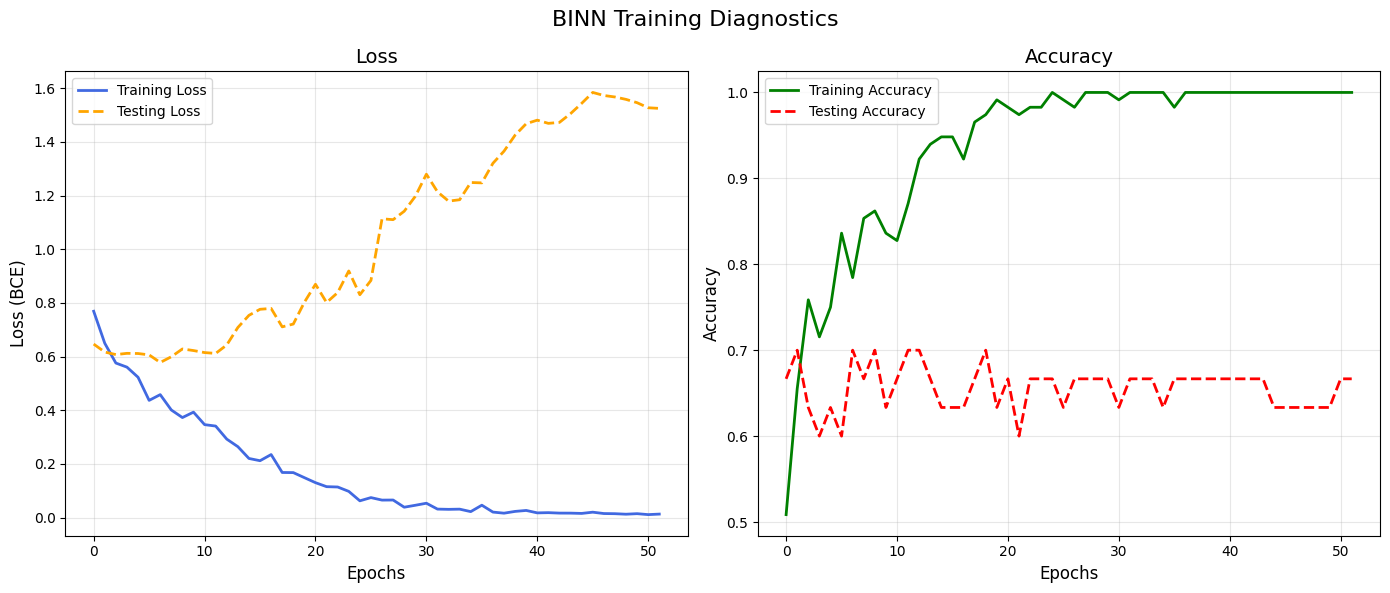

In [119]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# Loss plot
axes[0].plot(history['train_loss'], label='Training Loss', color='royalblue', linewidth=2)
axes[0].plot(history['test_loss'], label='Testing Loss', color='orange', linestyle='--', linewidth=2)
axes[0].set_title('Loss', fontsize=14)
axes[0].set_xlabel('Epochs', fontsize=12)
axes[0].set_ylabel('Loss (BCE)', fontsize=12)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy plot
axes[1].plot(history['train_acc'], label='Training Accuracy', color='green', linewidth=2)
axes[1].plot(history['test_acc'], label='Testing Accuracy', color='red', linestyle='--', linewidth=2)
axes[1].set_title('Accuracy', fontsize=14)
axes[1].set_xlabel('Epochs', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('BINN Training Diagnostics', fontsize=16)
plt.tight_layout()
plt.show()

In [120]:
# CROSS VALIDATION
all_fold_scores = dh.run_cross_validation(adata_global, in_features, layers_list, tensor_masks, 
                                          device, k=5, epochs=EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY, 
                                          dropout=DROPOUT, activation_fn=ACTIVATION_FN)


--- Starting Fold 1/5 ---


/data/users/thomath/kand/BINN/data_handling.py:704: FutureWarning: The function AnnLoader is deprecated and will be removed in the future. Use :class:`annbatch.Loader` instead of `AnnLoader`
  train_loader = AnnLoader(train_sub, batch_size=batch_size, shuffle=True)
/data/users/thomath/kand/BINN/data_handling.py:705: FutureWarning: The function AnnLoader is deprecated and will be removed in the future. Use :class:`annbatch.Loader` instead of `AnnLoader`
  val_loader = AnnLoader(val_sub, batch_size=batch_size, shuffle=False)


Fold 1 Best Test AUC: 0.8750

--- Starting Fold 2/5 ---


/data/users/thomath/kand/BINN/data_handling.py:704: FutureWarning: The function AnnLoader is deprecated and will be removed in the future. Use :class:`annbatch.Loader` instead of `AnnLoader`
  train_loader = AnnLoader(train_sub, batch_size=batch_size, shuffle=True)
/data/users/thomath/kand/BINN/data_handling.py:705: FutureWarning: The function AnnLoader is deprecated and will be removed in the future. Use :class:`annbatch.Loader` instead of `AnnLoader`
  val_loader = AnnLoader(val_sub, batch_size=batch_size, shuffle=False)


Fold 2 Best Test AUC: 0.9231

--- Starting Fold 3/5 ---


...

Fold 3 Best Test AUC: 0.7308

--- Starting Fold 4/5 ---


/data/users/thomath/kand/BINN/data_handling.py:704: FutureWarning: The function AnnLoader is deprecated and will be removed in the future. Use :class:`annbatch.Loader` instead of `AnnLoader`
  train_loader = AnnLoader(train_sub, batch_size=batch_size, shuffle=True)
/data/users/thomath/kand/BINN/data_handling.py:705: FutureWarning: The function AnnLoader is deprecated and will be removed in the future. Use :class:`annbatch.Loader` instead of `AnnLoader`
  val_loader = AnnLoader(val_sub, batch_size=batch_size, shuffle=False)


Fold 4 Best Test AUC: 0.8905

--- Starting Fold 5/5 ---


/data/users/thomath/kand/BINN/data_handling.py:704: FutureWarning: The function AnnLoader is deprecated and will be removed in the future. Use :class:`annbatch.Loader` instead of `AnnLoader`
  train_loader = AnnLoader(train_sub, batch_size=batch_size, shuffle=True)
/data/users/thomath/kand/BINN/data_handling.py:705: FutureWarning: The function AnnLoader is deprecated and will be removed in the future. Use :class:`annbatch.Loader` instead of `AnnLoader`
  val_loader = AnnLoader(val_sub, batch_size=batch_size, shuffle=False)


Fold 5 Best Test AUC: 0.7905

Mean ROC-AUC: 0.8420 +/- 0.0708


In [121]:
# Hyperparameter tuning, takes a while 
#best_params = dh.hyperparameter_tuning_optuna(adata_global, in_features, layers_list, tensor_masks, 
#                                              device, batch_size=BATCH_SIZE, activation_fn=ACTIVATION_FN,
#                                              k=5, epochs=EPOCHS)

Best train Loss: 0.0113 found at epoch 50 | Best train acc: 1.0000 found at epoch 24 || Best test Loss: 0.5780 found at epoch 6 | Best test acc: 0.7000 found at epoch 1
Saved: binn_test_results.csv


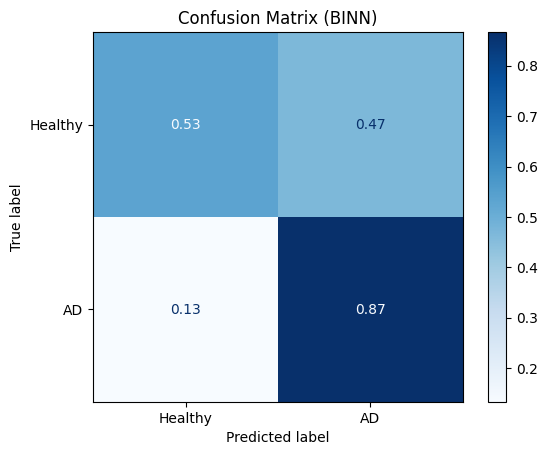

In [122]:
best_metrics = dh.fetch_best_metrics(history)
df_res = dh.save_test_results(binn, test_loader_global, device)
dh.confusion_matrix_binn(df_res)

In [123]:
report = dh.class_report(df_res)
report

Classification report for BINN:               precision    recall  f1-score   support

         0.0       0.80      0.53      0.64        15
         1.0       0.65      0.87      0.74        15

    accuracy                           0.70        30
   macro avg       0.73      0.70      0.69        30
weighted avg       0.72      0.70      0.69        30



'              precision    recall  f1-score   support\n\n         0.0       0.80      0.53      0.64        15\n         1.0       0.65      0.87      0.74        15\n\n    accuracy                           0.70        30\n   macro avg       0.73      0.70      0.69        30\nweighted avg       0.72      0.70      0.69        30\n'